In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import joblib

In [2]:
try:
    from xgboost import XGBClassifier
    xgb_available = True
except:
    xgb_available = False
    print("WARNING: XGBoost is not installed. To install: pip install xgboost")

In [3]:
df = pd.read_csv(r"C:\Users\Ausu tuf\Music\project\DATASET\sampled_train_dataset.csv")
print(df.head())

       ip  app  device   os  channel           click_time attributed_time  \
0  100212   17       1  185      280  2017-11-07 01:18:53             NaN   
1    7178    1       1   40      349  2017-11-06 17:06:59             NaN   
2   64187    9       1   20      334  2017-11-09 13:04:59             NaN   
3   48953    2       1    4      219  2017-11-07 01:23:56             NaN   
4   66184    8       1   19      145  2017-11-06 16:29:44             NaN   

   is_attributed  
0              0  
1              0  
2              0  
3              0  
4              0  


In [4]:
# Load Data
# -------------------------
df = pd.read_csv(r"C:\Users\Ausu tuf\Music\project\DATASET\sampled_train_dataset.csv")
test_df = pd.read_csv(r"C:\Users\Ausu tuf\Music\project\DATASET\sampled_test_dataset.csv")

print("Train:", df.shape)
print("Test:", test_df.shape)

Train: (10000, 8)
Test: (500, 7)


In [5]:
df.describe()

,ip,app,device,os,channel,is_attributed
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,89111.502600,12.513600,31.315500,24.592900,257.55810,0.002600
std,63260.753753,15.568245,304.763638,62.219433,130.22617,0.050926
min,45.000000,0.000000,0.000000,0.000000,3.00000,0.000000
25%,42200.000000,3.000000,1.000000,13.000000,135.00000,0.000000
50%,80779.500000,12.000000,1.000000,18.000000,245.00000,0.000000
75%,119320.000000,15.000000,1.000000,19.000000,377.00000,0.000000
max,364758.000000,525.000000,3866.000000,866.000000,497.00000,1.000000


In [6]:
df.head()

,ip,app,device,os,channel,click_time,attributed_time,is_attributed
0,100212,17,1,185,280,2017-11-07 01:18:53,NaN,0
1,7178,1,1,40,349,2017-11-06 17:06:59,NaN,0
2,64187,9,1,20,334,2017-11-09 13:04:59,NaN,0
3,48953,2,1,4,219,2017-11-07 01:23:56,NaN,0
4,66184,8,1,19,145,2017-11-06 16:29:44,NaN,0


In [7]:
df.isnull()

,ip,app,device,os,channel,click_time,attributed_time,is_attributed
0,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,True,False
9996,False,False,False,False,False,False,True,False
9997,False,False,False,False,False,False,True,False
9998,False,False,False,False,False,False,True,False


In [8]:
def feature_engineering(df):
    df = df.copy()
    df["click_time"] = pd.to_datetime(df["click_time"])

    df["hour"] = df["click_time"].dt.hour
    df["day"] = df["click_time"].dt.day
    df["weekday"] = df["click_time"].dt.weekday
    df["minute"] = df["click_time"].dt.minute

    df["epoch"] = df["click_time"].astype('int64') // 1e9

    df = df.sort_values(["ip", "click_time"])
    df["prev_epoch"] = df.groupby("ip")["epoch"].shift(1)
    df["click_gap"] = df["epoch"] - df["prev_epoch"]
    df["click_gap"] = df["click_gap"].fillna(0)

    df["ip_click_count"] = df["ip"].map(df["ip"].value_counts().to_dict())

    df["is_night"] = ((df["hour"] >= 0) & (df["hour"] <= 6)).astype(int)

    return df

df = feature_engineering(df)
test_df = feature_engineering(test_df)


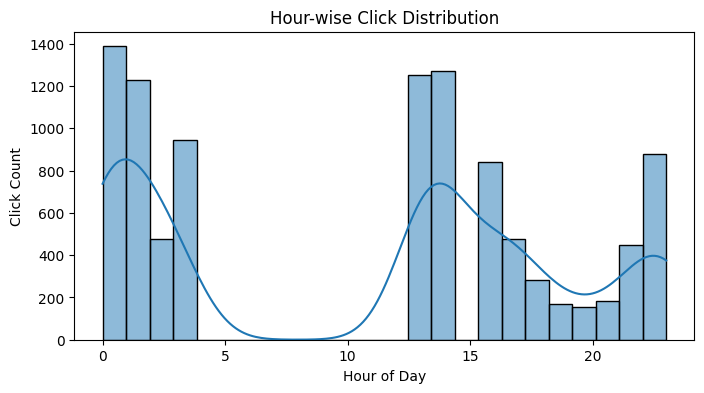

In [9]:
plt.figure(figsize=(8,4))
sns.histplot(df["hour"], bins=24, kde=True)
plt.title("Hour-wise Click Distribution")
plt.xlabel("Hour of Day")
plt.ylabel("Click Count")
plt.show()


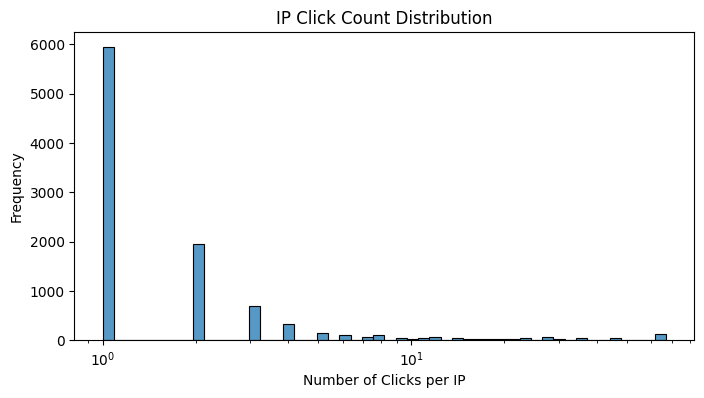

In [10]:
plt.figure(figsize=(8,4))
sns.histplot(df["ip_click_count"], bins=50, log_scale=True)
plt.title("IP Click Count Distribution")
plt.xlabel("Number of Clicks per IP")
plt.ylabel("Frequency")
plt.show()


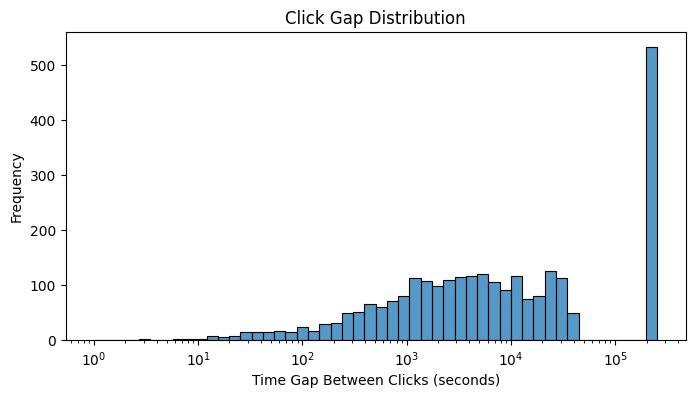

In [11]:
plt.figure(figsize=(8,4))
sns.histplot(df["click_gap"], bins=50, log_scale=True)
plt.title("Click Gap Distribution")
plt.xlabel("Time Gap Between Clicks (seconds)")
plt.ylabel("Frequency")
plt.show()


In [12]:
# Select Features
# -------------------------
features = [
    "ip","app","device","os","channel",
    "hour","weekday","minute",
    "click_gap","ip_click_count","is_night"
]



In [13]:
# -------------------------
# Train-Test Split
# -------------------------
X = df[features]
y = df["is_attributed"].astype(int)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

In [14]:
# Preprocessing
# -------------------------
num_features = ["hour","weekday","minute","click_gap","ip_click_count","is_night"]
cat_features = ["ip","app","device","os","channel"]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_features),
    ("cat", categorical_transformer, cat_features)
])

In [15]:
# -------------------------
# Model: RandomForest
# -------------------------
rf_pipeline = Pipeline([
    ("pre", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=250,
        max_depth=15,
        n_jobs=-1,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)
print("RandomForest trained!")


RandomForest trained!


In [16]:
# ================================
# 7. XGBOOST 
# ================================
if xgb_available:
    xgb_pipeline = Pipeline([
        ("pre", preprocessor),
        ("clf", XGBClassifier(
            n_estimators=300,
            max_depth=8,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss"
        ))
    ])
    xgb_pipeline.fit(X_train, y_train)
    print("XGBoost trained!")

In [17]:
# 8. EVALUATION FUNCTION
# ================================
def evaluate(model, name):
    print(f"\n=== {name} Report ===")
    y_pred = model.predict(X_valid)
    y_prob = model.predict_proba(X_valid)[:,1]

    print(classification_report(y_valid, y_pred))

    cm = confusion_matrix(y_valid, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.show()

    fpr, tpr, _ = roc_curve(y_valid, y_prob)
    auc_score = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"AUC={auc_score:.4f}")
    plt.plot([0,1],[0,1],"k--")
    plt.title(f"{name} ROC Curve")
    plt.legend()
    plt.show()

    return auc_score


In [18]:
import sklearn
!pip install xgboost
import xgboost

print("sklearn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)


  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
sklearn: 1.7.2
xgboost: 3.2.0



=== RandomForest Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2992
           1       1.00      0.25      0.40         8

    accuracy                           1.00      3000
   macro avg       1.00      0.62      0.70      3000
weighted avg       1.00      1.00      1.00      3000



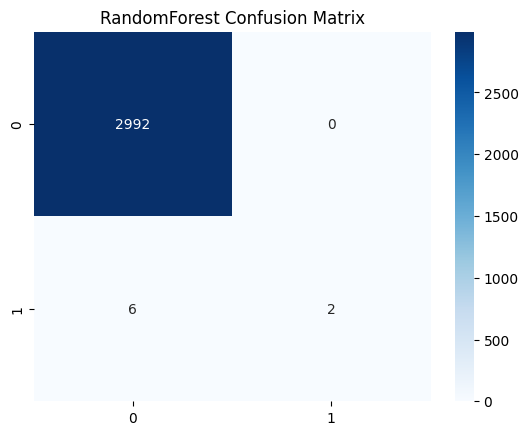

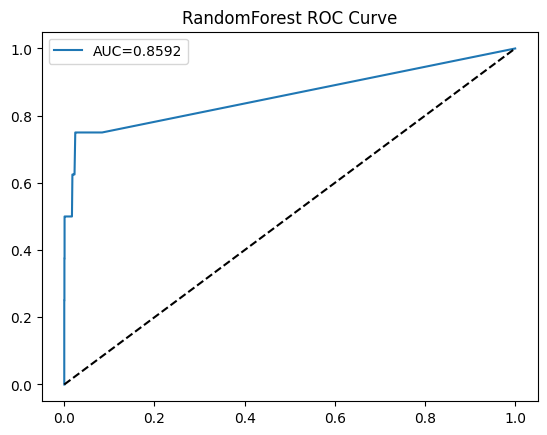

In [19]:
# 9. MODEL EVALUATION
# ================================
rf_auc = evaluate(rf_pipeline, "RandomForest")

if xgb_available:
    xgb_auc = evaluate(xgb_pipeline, "XGBoost")
else:
    xgb_auc = -1

In [20]:
!pip install xgboost



In [21]:
best_model = rf_pipeline if rf_auc >= xgb_auc else xgb_pipeline
best_name = "RandomForest" if best_model is rf_pipeline else "XGBoost"

print("Best model =", best_name)


Best model = RandomForest


In [22]:
os.makedirs("./model", exist_ok=True)
joblib.dump(best_model, "./model/model.pkl")
joblib.dump(features, "./model/features.pkl")

print("Model saved successfully!")

Model saved successfully!
